In [1]:
import pandas as pd

BASE_DIR = "cleaned_output/Fitbit_vi_cleaned"

sleep_df = pd.read_excel(f"{BASE_DIR}/Fitbit_vi_sleep_score_cleaned.xlsx")
stress_df = pd.read_excel(f"{BASE_DIR}/Fitbit_vi_stress_score_cleaned.xlsx")
activity_df = pd.read_excel(f"{BASE_DIR}/Fitbit_vi_active_zone_minutes_(azm)_cleaned.xlsx")
hrv_df = pd.read_excel(f"{BASE_DIR}/Fitbit_vi_heart_rate_variability_cleaned.xlsx")
oxygen_df = pd.read_excel(f"{BASE_DIR}/Fitbit_vi_oxygen_saturation_(spo2)_cleaned.xlsx")
temp_df = pd.read_excel(f"{BASE_DIR}/Fitbit_vi_temperature_cleaned.xlsx")


In [2]:
sleep_df["date"] = pd.to_datetime(sleep_df["timestamp"], errors="coerce").dt.date

sleep_daily = (
    sleep_df
    .groupby("date")["overall_score"]
    .mean()
    .reset_index(name="sleep_score")
)


In [3]:
stress_df["date"] = pd.to_datetime(stress_df["date"], errors="coerce").dt.date

stress_daily = (
    stress_df
    .groupby("date")["stress_score"]
    .mean()
    .reset_index()
)


In [4]:
activity_df["date"] = pd.to_datetime(activity_df["date_time"], errors="coerce").dt.date

activity_daily = (
    activity_df
    .groupby("date")["total_minutes"]
    .sum()
    .reset_index(name="active_minutes")
)


In [5]:
hrv_df["date"] = pd.to_datetime(hrv_df["timestamp"], errors="coerce").dt.date

hrv_daily = (
    hrv_df
    .groupby("date")["rmssd"]
    .mean()
    .reset_index()
)


In [7]:
temp_df["date"] = pd.to_datetime(temp_df["recorded_time"], errors="coerce").dt.date

temp_daily = (
    temp_df
    .groupby("date")["temperature"]
    .mean()
    .reset_index(name="nightly_temp")
)


In [12]:
# Convert sleep_start to date
temp_df["date"] = pd.to_datetime(
    temp_df["sleep_start"],
    errors="coerce"
).dt.date

# Drop rows where date is missing
temp_df = temp_df.dropna(subset=["date"])

# Daily nightly temperature average
temp_daily = (
    temp_df
    .groupby("date")["temperature"]
    .mean()
    .reset_index(name="nightly_temp")
)

temp_daily.head()


,date,nightly_temp
0,2025-06-26,0.0
1,2025-06-30,0.0
2,2025-07-02,0.0
3,2025-07-05,0.0
4,2025-07-07,0.0


In [8]:
sleep_stress = pd.merge(sleep_daily, stress_daily, on="date", how="inner")
sleep_stress[["sleep_score", "stress_score"]].corr()


,sleep_score,stress_score
sleep_score,1.000000,-0.009924
stress_score,-0.009924,1.000000


In [9]:
stress_hrv = pd.merge(hrv_daily, stress_daily, on="date", how="inner")
stress_hrv[["rmssd", "stress_score"]].corr()


,rmssd,stress_score
rmssd,1.000000,0.358628
stress_score,0.358628,1.000000


In [10]:
activity_stress = pd.merge(activity_daily, stress_daily, on="date", how="inner")
activity_stress[["active_minutes", "stress_score"]].corr()


,active_minutes,stress_score
active_minutes,1.000000,0.411895
stress_score,0.411895,1.000000


In [11]:
sleep_hrv = pd.merge(sleep_daily, hrv_daily, on="date", how="inner")
sleep_hrv[["sleep_score", "rmssd"]].corr()


,sleep_score,rmssd
sleep_score,1.000000,0.403377
rmssd,0.403377,1.000000


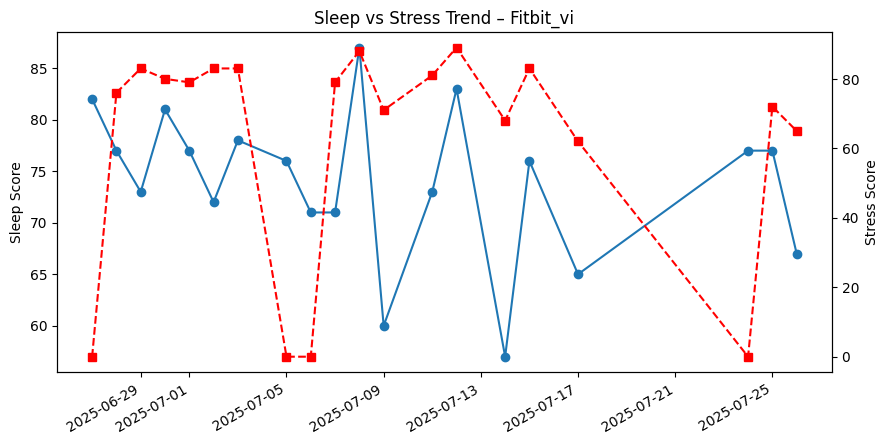

In [13]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    sleep_stress["date"],
    sleep_stress["sleep_score"],
    marker="o",
    label="Sleep Score"
)
ax1.set_ylabel("Sleep Score")

ax2 = ax1.twinx()
ax2.plot(
    sleep_stress["date"],
    sleep_stress["stress_score"],
    marker="s",
    linestyle="--",
    color="red",
    label="Stress Score"
)
ax2.set_ylabel("Stress Score")

plt.title("Sleep vs Stress Trend – Fitbit_vi")
fig.autofmt_xdate()
plt.show()


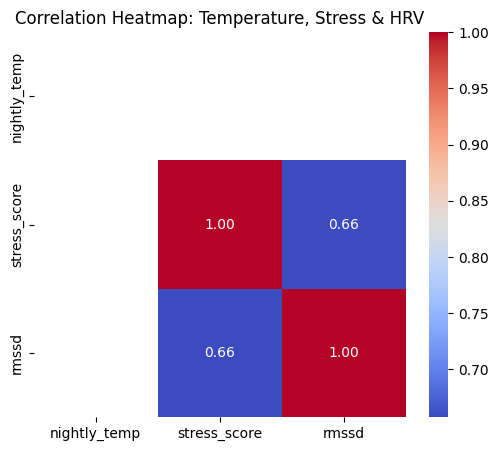

In [15]:
import seaborn as sns

combined = (
    temp_daily
    .merge(stress_daily, on="date", how="inner")
    .merge(hrv_daily, on="date", how="inner")
)

corr = combined[["nightly_temp", "stress_score", "rmssd"]].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap: Temperature, Stress & HRV")
plt.show()


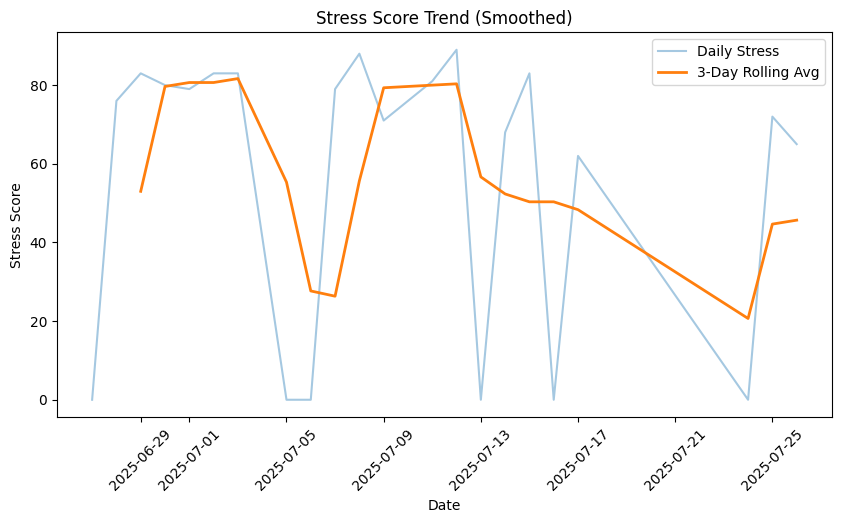

In [16]:
stress_daily_sorted = stress_daily.sort_values("date")
stress_daily_sorted["rolling_stress"] = (
    stress_daily_sorted["stress_score"].rolling(window=3).mean()
)

plt.figure(figsize=(10,5))
plt.plot(stress_daily_sorted["date"], stress_daily_sorted["stress_score"],
         alpha=0.4, label="Daily Stress")
plt.plot(stress_daily_sorted["date"], stress_daily_sorted["rolling_stress"],
         linewidth=2, label="3-Day Rolling Avg")
plt.title("Stress Score Trend (Smoothed)")
plt.xlabel("Date")
plt.ylabel("Stress Score")
plt.legend()
plt.xticks(rotation=45)
plt.show()


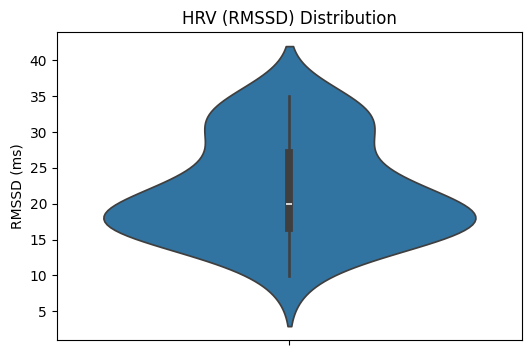

In [17]:
plt.figure(figsize=(6,4))
sns.violinplot(y=hrv_daily["rmssd"])
plt.title("HRV (RMSSD) Distribution")
plt.ylabel("RMSSD (ms)")
plt.show()


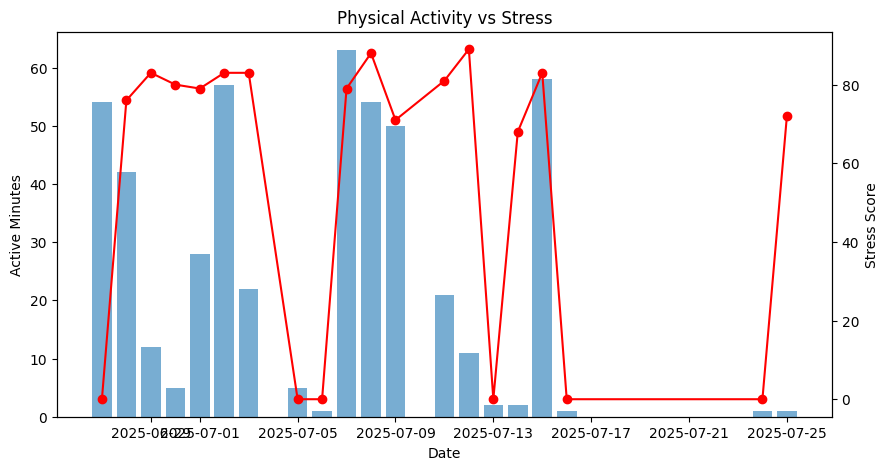

In [18]:
merged = pd.merge(activity_daily, stress_daily, on="date", how="inner")

fig, ax1 = plt.subplots(figsize=(10,5))

ax1.bar(merged["date"], merged["active_minutes"],
        alpha=0.6, label="Active Minutes")
ax1.set_ylabel("Active Minutes")

ax2 = ax1.twinx()
ax2.plot(merged["date"], merged["stress_score"],
         color="red", marker="o", label="Stress Score")
ax2.set_ylabel("Stress Score")

plt.title("Physical Activity vs Stress")
ax1.set_xlabel("Date")
plt.xticks(rotation=45)
plt.show()
